### **Visualization Geospatial Analysis**

#### **SETUP & DATA LOADING**

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path
from shapely import wkt

# ---- Paths ----
ROOT           = Path().resolve().parent
GEOCODED_FILE  = ROOT / "data" / "geocoded_output" / "geocoded_output.gpkg"
COUNTIES_SHP   = ROOT / "tl_2024_us_county" / "tl_2024_us_county.shp"

# ---- Settings ----
KANSAS_FIPS    = "20"
CRS_GEOGRAPHIC = "EPSG:4326"
CRS_PROJECTED  = "EPSG:32614"   # UTM Zone 14N — Kansas


In [4]:
# Loading geocoded output from pipeline
bwa_gdf = gpd.read_file(GEOCODED_FILE)
bwa_gdf = bwa_gdf.to_crs(epsg=4326)

# Restoring buffer geometry from WKT string back to geometry
# Step 1: Parse WKT to Shapely geometries
bwa_gdf["buffer_geometry"] = bwa_gdf["buffer_geometry"].apply(wkt.loads)

# Step 2: Convert to GeoSeries so GeoPandas recognizes it as geometry
bwa_gdf["buffer_geometry"] = gpd.GeoSeries(bwa_gdf["buffer_geometry"], crs=bwa_gdf.crs)

print(f"Loaded {len(bwa_gdf)} BWA records")
bwa_gdf.head(2)

Loaded 265 BWA records


,Advisory_Notice_URL,Federal_ID,PWS_Name,PWS_Type,Issues_Date,Rescinded_Date,Advisory_Context,Advisory_Reason,Advisory_Category,Year,...,Population_Served,District,City,County,No._of_Violations,county_clean,lat,lon,buffer_geometry,geometry
0,https://www.kdhe.ks.gov/m/newsflash/Home/Detai...,KS2013913,"QUENEMO, CITY OF",Community water system,2024-02-28,2024-03-15,KDHE officials issued the advisory because of ...,line break,infrastructure_failure,2024,...,287,NE,QUENEMO,Osage,12,OSAGE,38.5797331,-95.5269256,"POLYGON ((812552.11492 4275863.06045, 812503.9...",POINT (-95.52693 38.57973)
1,https://www.kdhe.ks.gov/m/newsflash/Home/Detai...,KS2013913,"QUENEMO, CITY OF",Community water system,2024-03-05,2024-03-15,KDHE officials issued the advisory because of ...,low pressure,infrastructure_failure,2024,...,287,NE,QUENEMO,Osage,12,OSAGE,38.5797331,-95.5269256,"POLYGON ((812552.11492 4275863.06045, 812503.9...",POINT (-95.52693 38.57973)


In [8]:
# Load Kansas counties
us_counties = gpd.read_file(COUNTIES_SHP).to_crs(CRS_GEOGRAPHIC)
ks_counties = us_counties[us_counties["STATEFP"] == KANSAS_FIPS].copy()

print(f"Loaded {len(bwa_gdf)} BWA records across {len(ks_counties)} Kansas counties")

Loaded 265 BWA records across 105 Kansas counties


### **DATA CLEANING & PREPARATION**

In [6]:
# To clean population to numeric
bwa_gdf['Population_Served_Clean'] = (
    bwa_gdf['Population_Served']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.replace(' ', '', regex=False)
    .astype(float)
)

# Ensuring coordinate fields are numeric
bwa_gdf['lat'] = bwa_gdf['lat'].astype(float)
bwa_gdf['lon'] = bwa_gdf['lon'].astype(float)

print("Data cleaning complete")
print(bwa_gdf[['PWS_Name', 'County', 'Population_Served', 'Population_Served_Clean']].head())

Data cleaning complete
              PWS_Name     County Population_Served  Population_Served_Clean
0     QUENEMO, CITY OF      Osage               287                    287.0
1     QUENEMO, CITY OF      Osage               287                    287.0
2  FALL RIVER, CITY OF  Greenwood               129                    129.0
3     PEABODY, CITY OF     Marion               932                    932.0
4   KANOPOLIS, CITY OF  Ellsworth               453                    453.0


#### **Visualizing Advisories Per County**

In [9]:
# Count advisories per county
county_counts = bwa_gdf["County"].value_counts().reset_index()
county_counts.columns = ["NAME", "bwa_count"]

ks_map = ks_counties.merge(county_counts, on="NAME", how="left")
ks_map["bwa_count"] = ks_map["bwa_count"].fillna(0)

c:\Users\aarun\anaconda3\envs\geospatial_env\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
c:\Users\aarun\anaconda3\envs\geospatial_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


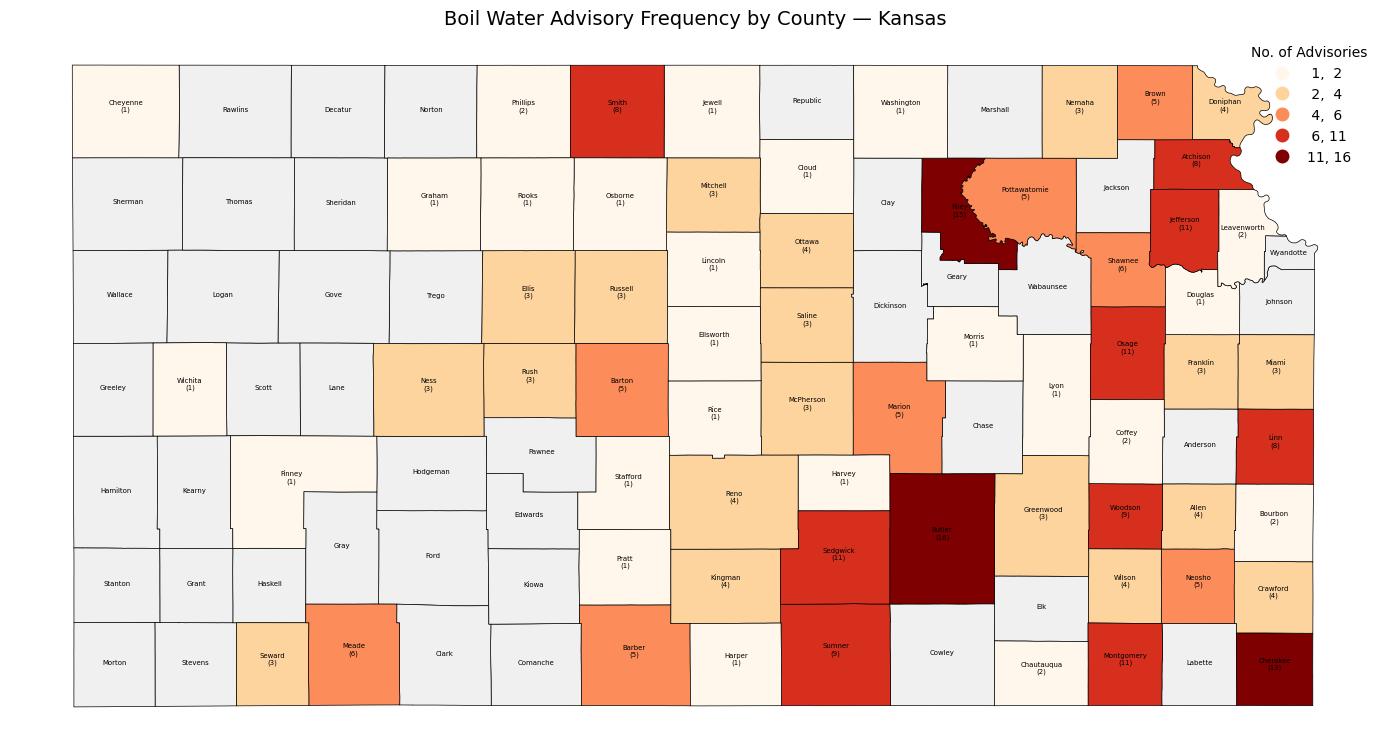

In [10]:
fig, ax = plt.subplots(figsize=(14, 9))

# Zero counties in gray first
ks_map[ks_map["bwa_count"] == 0].plot(
    ax=ax, color="#f0f0f0", edgecolor="black", linewidth=0.5
)
ks_map[ks_map["bwa_count"] > 0].plot(
    ax=ax,
    column="bwa_count",
    cmap="OrRd",
    edgecolor="black",
    linewidth=0.5,
    legend=True,
    scheme="NaturalBreaks",
    k=5,
    legend_kwds={"title": "No. of Advisories", "fmt": "{:.0f}", "frameon": False}
)
for _, row in ks_map.iterrows():
    ax.annotate(
        f"{row['NAME']}\n({int(row['bwa_count'])})" if row["bwa_count"] > 0 else row["NAME"],
        xy=(row.geometry.centroid.x, row.geometry.centroid.y),
        fontsize=5, ha="center", color="black"
    )

ax.set_title("Boil Water Advisory Frequency by County — Kansas", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()